# Crypto momentum

30-day momentum rule returned 96.50% in 2024–2025 after modelled costs, versus 37.59% for the half-crypto/half-cash benchmark. The primary 95% confidence interval for the Sharpe difference includes zero, hence no statistical edge proven, despite positive results.

This notebook serves as a brief overview of the [original research notebook](archive/crypto_momentum_research_2026-09-16.ipynb), preserving the main research pattern without all the nitty-gritty details.

### Imports and setup
BTC, ETH (both GBP) daily Coinbase data from 01/01/2019–31/12/2025. Loader resolves recorded snapshot within this checkout, filters request boundaries, with data defects excluded here.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display
%matplotlib inline
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "research/holdout_protocol_v1.json").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import crypto_preparation, crypto_features, crypto_portfolio, crypto_backtest
import crypto_reporting, crypto_validation, crypto_sweep, crypto_holdout, crypto_replay

METRICS = ["total_return", "cagr", "annualised_volatility","sharpe_zero_cash_rate", "max_drawdown", "mean_crypto_weight"]
FORMATS = {name: "{:.2%}" for name in METRICS}
FORMATS.update(sharpe_zero_cash_rate="{:.3f}", annualised_one_way_turnover="{:.2f}")

In [ ]:
study = crypto_replay.load_frozen_study(PROJECT_ROOT)
STUDY_SPEC = study["study_spec"]
SYMBOLS = STUDY_SPEC["symbols"]
run_dir = study["run_dir"]
holdout_protocol_path = study["protocol_path"]
frozen_protocol = study["protocol_record"]["protocol"]
development_end = pd.Timestamp(STUDY_SPEC["development_end_exclusive"], tz="UTC")
normalised_prices, price_audit = crypto_preparation.audit_daily_prices(
    prices=study["prices"], symbols=SYMBOLS,
    start=pd.Timestamp(STUDY_SPEC["data_start"], tz="UTC"),
    end=pd.Timestamp(STUDY_SPEC["holdout_end_exclusive"], tz="UTC"),
)
assert price_audit["passed"].all(), "Resolve the data audit before evaluation."
development_prices = normalised_prices.loc[normalised_prices.timestamp < development_end].copy()
other_cost_bps = STUDY_SPEC["provisional_round_trip_cost_bps"] / 2 - STUDY_SPEC["taker_fee_bps_per_side"]
BACKTEST = dict(symbols=SYMBOLS, initial_cash=1_000.0, fee_bps=STUDY_SPEC["taker_fee_bps_per_side"], other_cost_bps=other_cost_bps)
print(f"Frozen requests: {study['saved_requests']}; snapshot: {run_dir.name}")
display(price_audit.T)

Frozen requests: 22; snapshot: coinbase_history_20260915T201604_090041Z


symbol,BTC-GBP,ETH-GBP
rows,2557,2557
expected_days,2557,2557
missing_days,0,0
invalid_timestamp_rows,0,0
outside_range_rows,0,0
off_midnight_rows,0,0
duplicate_rows,0,0
nonfinite_numeric_rows,0,0
nonpositive_price_rows,0,0
invalid_ohlc_rows,0,0


## Benchmarks, 90d momentum (original) rule, calibration

The strategy implements the following. Over the past 90d, were the (close to close) returns strictly positive? If so, then buy. If not, then stick with cash. This is applied to BTC and ETH independently, with equal weighting. If one of the assets has positive returns, but the other doesn't, then the portfolio has 50:50 cash:crypto ratio. This is sometimes referred to as absolute momentum.

Decisions use completed candles at Monday 00:00 UTC, with execution at Tuesday's opening reference price. We allow weights to drift between rebalances (weekly). Fractional units are allowed (no interest on cash). Assume each sided traded costs 9bp transaction (in line with Revolut X offerings), with 3.5bp other execution costs (spreading/slipping etc), leading to 25bp round trip

The initial comparison covers common baseline history from 04/2019-12/2023 (inclusive). Later comparisons use 2021–2023, so their returns are not directly comparable with this table.

In [ ]:
development_features = crypto_features.add_momentum_features(prices=development_prices, lookback_days=STUDY_SPEC["signal_lookback_days"])
weekly_targets = crypto_portfolio.build_weekly_targets(features=development_features, symbols=SYMBOLS, execution_end=development_end)
baseline_targets = {
    "momentum_90d": weekly_targets,
    "buy_and_hold": crypto_portfolio.build_benchmark_targets(weekly_targets, SYMBOLS, mode="buy_and_hold"),
    "weekly_equal_weight": crypto_portfolio.build_benchmark_targets(weekly_targets, SYMBOLS, mode="weekly"),
    "half_crypto_half_cash": crypto_portfolio.build_constant_mix_targets(weekly_targets, SYMBOLS, crypto_weight=0.5)
}
baseline_runs = {name: crypto_backtest.run_daily_backtest(development_prices, targets, **BACKTEST) for name, targets in baseline_targets.items()}
development_ledgers = {name: result[0] for name, result in baseline_runs.items()}
development_ledger, development_trades = baseline_runs["momentum_90d"]
assert all(ledger.index.equals(development_ledger.index) for ledger in development_ledgers.values())
display(crypto_replay.summarise_ledgers(development_ledgers)[METRICS].style.format(FORMATS))

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight
momentum_90d,356.93%,37.87%,57.09%,0.858,-63.40%,60.46%
buy_and_hold,958.17%,64.65%,74.33%,1.051,-74.47%,100.00%
weekly_equal_weight,1081.50%,68.53%,72.96%,1.089,-73.04%,100.00%
half_crypto_half_cash,368.92%,38.63%,36.25%,1.084,-44.99%,50.12%


See that 90d momentum performs poorly here against buy-and-hold, and rebalancing weekly to ensure 50/50 BTC:ETH splits. This leads to discuss different benchmarks, and later, different lookback days.

Now evaluate on 2021, 2022 and 2023, with each calibration window expanding from 2019, and ends before its evaluation year begins. A diagnostic benchmark uses original strategy's past average crypto exposure, splitting it equally between BTC and ETH, with the rest in cash.

The fixed 25% BTC / 25% ETH / 50% cash portfolio is the later primary benchmark. Calibration is a separate development comparison.

In [4]:
evaluation_windows = crypto_validation.build_annual_evaluation_windows(
    data_start=pd.Timestamp(STUDY_SPEC["data_start"], tz="UTC"),
    first_test_start=pd.Timestamp("2021-01-01", tz="UTC"), evaluation_end=development_end)
evaluation_start = evaluation_windows["test_start"].min()
benchmark_allocations = crypto_validation.calibrate_benchmark_allocations(development_ledger, evaluation_windows)
calibrated_targets = crypto_portfolio.build_calibrated_mix_targets(
    weekly_targets, SYMBOLS, evaluation_windows, benchmark_allocations)
calibrated_ledger, calibrated_trades = crypto_backtest.run_daily_backtest(
    development_prices, calibrated_targets, **BACKTEST)
display(evaluation_windows)
display(benchmark_allocations[["crypto_weight", "cash_weight"]].style.format("{:.2%}"))
display(crypto_replay.summarise_ledgers(
    {**development_ledgers, "calibrated_crypto_cash": calibrated_ledger},
    evaluation_start, development_end)[METRICS].style.format(FORMATS))

,calibration_start,calibration_end,test_start,test_end
fold,,,,
1,2019-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,2021-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00
2,2019-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00,2022-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00
3,2019-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2023-01-01 00:00:00+00:00,2024-01-01 00:00:00+00:00


,crypto_weight,cash_weight
fold,,
1,68.50%,31.50%
2,73.28%,26.72%
3,59.00%,41.00%


,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight
momentum_90d,87.23%,23.27%,50.92%,0.666,-60.75%,55.81%
buy_and_hold,132.24%,32.45%,72.41%,0.753,-74.47%,100.00%
weekly_equal_weight,147.21%,35.24%,69.53%,0.784,-73.04%,100.00%
half_crypto_half_cash,88.15%,23.47%,34.49%,0.784,-44.99%,50.12%
calibrated_crypto_cash,84.89%,22.75%,47.53%,0.670,-59.32%,66.97%


## Sweep

Now sweep across different lookback days to see which performs best on the testing period.

In [5]:
LOOKBACKS = tuple(frozen_protocol["annual_selection"]["lookbacks"])
sweep_summary, sweep_annual, sweep_runs = crypto_sweep.run_lookback_sweep(
    prices=development_prices, lookbacks=LOOKBACKS, windows=evaluation_windows, **BACKTEST)
sweep_comparison = crypto_replay.summarise_ledgers(
    {**{f"momentum_{days}d": run["ledger"] for days, run in sweep_runs.items()},
     **{name: development_ledgers[name] for name in ("half_crypto_half_cash", "weekly_equal_weight")}},
    evaluation_start, development_end)
display(sweep_comparison[METRICS + ["annualised_one_way_turnover"]].style.format(FORMATS))
display(sweep_annual["total_return"].unstack("year").style.format("{:.2%}"))

,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight,annualised_one_way_turnover
momentum_1d,14.02%,4.47%,44.61%,0.322,-67.24%,49.72%,27.50
momentum_3d,26.96%,8.29%,47.42%,0.407,-62.50%,53.72%,25.19
momentum_7d,31.49%,9.56%,48.63%,0.432,-54.28%,53.10%,27.35
momentum_14d,-7.24%,-2.48%,49.82%,0.202,-64.25%,53.18%,18.78
momentum_21d,119.78%,30.04%,50.62%,0.774,-46.38%,53.77%,14.16
momentum_30d,417.32%,73.01%,48.79%,1.369,-37.66%,51.12%,10.85
momentum_60d,132.12%,32.43%,51.60%,0.803,-54.55%,56.11%,6.91
momentum_90d,87.23%,23.27%,50.92%,0.666,-60.75%,55.81%,6.96
momentum_120d,198.89%,44.08%,52.99%,0.956,-48.27%,53.71%,5.37
momentum_180d,207.69%,45.48%,54.34%,0.964,-49.55%,60.44%,5.83


year,2021,2022,2023
lookback_days,,,
1,37.37%,-41.27%,41.34%
3,84.32%,-56.57%,58.58%
7,89.48%,-38.12%,12.15%
14,67.45%,-41.83%,-4.78%
21,91.25%,-16.63%,37.85%
30,277.72%,-22.93%,77.71%
60,156.47%,-40.11%,51.13%
90,142.04%,-39.07%,26.97%
120,169.45%,-22.90%,43.87%


By most metrics, the 30d momentum performs the best over this period, having the best performance in 2021 and 2023 by pretty sizable margins, and also the best Sharpe ratio.

Now select the rule based on the observations before each evaluation year (using same comparison grid). All candidates begin on same training date (03/07/2019) and continue through year boundaries (switching costs are applied). This is not a nested walk-forward. 

In [6]:
lookback_selections, selection_scores = crypto_validation.select_lookbacks_by_past_sharpe(
    sweep_runs, evaluation_windows)
selected_targets = crypto_portfolio.build_selected_momentum_targets(
    weekly_targets, SYMBOLS, sweep_runs, lookback_selections)
selected_ledger, selected_trades = crypto_backtest.run_daily_backtest(
    development_prices, selected_targets, **BACKTEST)
display(lookback_selections[["lookback_days", "training_start", "training_end", "training_sharpe"]]
        .style.format({"training_sharpe": "{:.3f}"}))
display(crypto_replay.summarise_ledgers(
    {"annual_selection": selected_ledger, "fixed_30d": sweep_runs[30]["ledger"],
     **{name: development_ledgers[name] for name in ("half_crypto_half_cash", "weekly_equal_weight")}},
    evaluation_start, development_end)[METRICS[:-1]].style.format(FORMATS))

,lookback_days,training_start,training_end,training_sharpe
fold,,,,
1,14,2019-07-03 00:00:00+00:00,2021-01-01 00:00:00+00:00,1.896
2,30,2019-07-03 00:00:00+00:00,2022-01-01 00:00:00+00:00,1.921
3,30,2019-07-03 00:00:00+00:00,2023-01-01 00:00:00+00:00,1.391


,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown
annual_selection,106.20%,27.30%,49.16%,0.739,-43.18%
fixed_30d,417.32%,73.01%,48.79%,1.369,-37.66%
half_crypto_half_cash,88.15%,23.47%,34.49%,0.784,-44.99%
weekly_equal_weight,147.21%,35.24%,69.53%,0.784,-73.04%


14d momentum performs better over the 2019-2020 period, with 30d momentum performing better over subsequent expanding training windows. 30d momentum also far outperforms the other benchmarks over this period in total returns, CAGR, Sharpe ratio and max-drawdown.

Now check the sensitivity to transaction costs. Test at 25, 40, 60bp round trip costs.

In [ ]:
cost_targets = {"momentum_30d": sweep_runs[30]["targets"], **{name: baseline_targets[name] for name in ("half_crypto_half_cash", "weekly_equal_weight")}}
cost_summary, cost_runs = crypto_sweep.run_cost_sensitivity(
    prices=development_prices, targets_by_strategy=cost_targets, symbols=SYMBOLS,
    windows=evaluation_windows, round_trip_costs=(25.0, 40.0, 60.0),
    initial_cash=1_000.0, fee_bps=STUDY_SPEC["taker_fee_bps_per_side"])
display(cost_summary[["total_return", "sharpe_zero_cash_rate", "max_drawdown"]].style.format(FORMATS))

See stability across transaction costs tested, with results worsening but only slightly. Even at 60bp, momentum still outperforms both benchmarks by a large margin.

Now fix the 30d momentum strategy, and compare with multiple benchmarks over the holdout period.

Primary statistic used is Sharpe difference, paired with a circular block bootstrap (10000 resamples, 28-day blocks and 95% percentile interval). Other block lengths are used primarily for sensitivity checking. Evidence of an edge requires primary interval lower bound above zero, with a positive strategy net return.

In [8]:
print("Protocol frozen:", study["protocol_record"]["frozen_at_utc"])
print("SHA-256:", study["protocol_record"]["protocol_sha256"])
primary_holdout = crypto_holdout.run_primary_holdout(
    prices=normalised_prices, protocol_path=holdout_protocol_path,
    prior_ledgers={"fixed_30d": sweep_runs[30]["ledger"],
                   "half_crypto_half_cash": development_ledgers["half_crypto_half_cash"]})
display(primary_holdout["performance"][METRICS].style.format(FORMATS))
display(primary_holdout["inference"][["sharpe_difference", "ci_lower", "ci_upper"]].style.format("{:.3f}"))
print("Primary evidence criterion met:", primary_holdout["primary_criterion_met"])

Protocol frozen: 2026-09-15T23:28:09.268356+00:00
SHA-256: cfea9a20fa884f93151d4877d27881f5080948b880755f859b726278bc171dea


,total_return,cagr,annualised_volatility,sharpe_zero_cash_rate,max_drawdown,mean_crypto_weight
fixed_30d,96.50%,40.15%,33.67%,1.170,-29.78%,48.49%
half_crypto_half_cash,37.59%,17.28%,27.36%,0.719,-27.32%,50.02%


,sharpe_difference,ci_lower,ci_upper
block_days,,,
28.000000,0.451,-0.605,1.374
14.000000,0.451,-0.573,1.413
56.000000,0.451,-0.586,1.365


Primary evidence criterion met: False


See that despite a noticeable outperformance by the 30d momentum strategy, the sharpe difference interval contains zero for each block day length, so no edge proven, but it does not prove that there is not an edge.

Now check to see which strategy would've been chosen above if the holdout period was included in the sweep above.

,lookback_days,training_end,training_sharpe
fold,,,
4,30,2024-01-01 00:00:00+00:00,1.441
5,30,2025-01-01 00:00:00+00:00,1.466


year,2024,2025
strategy,,
annual_past_sharpe_selection,75.35%,12.06%
fixed_30d,75.35%,12.06%
half_crypto_half_cash,42.99%,-3.78%
weekly_equal_weight,85.26%,-12.95%


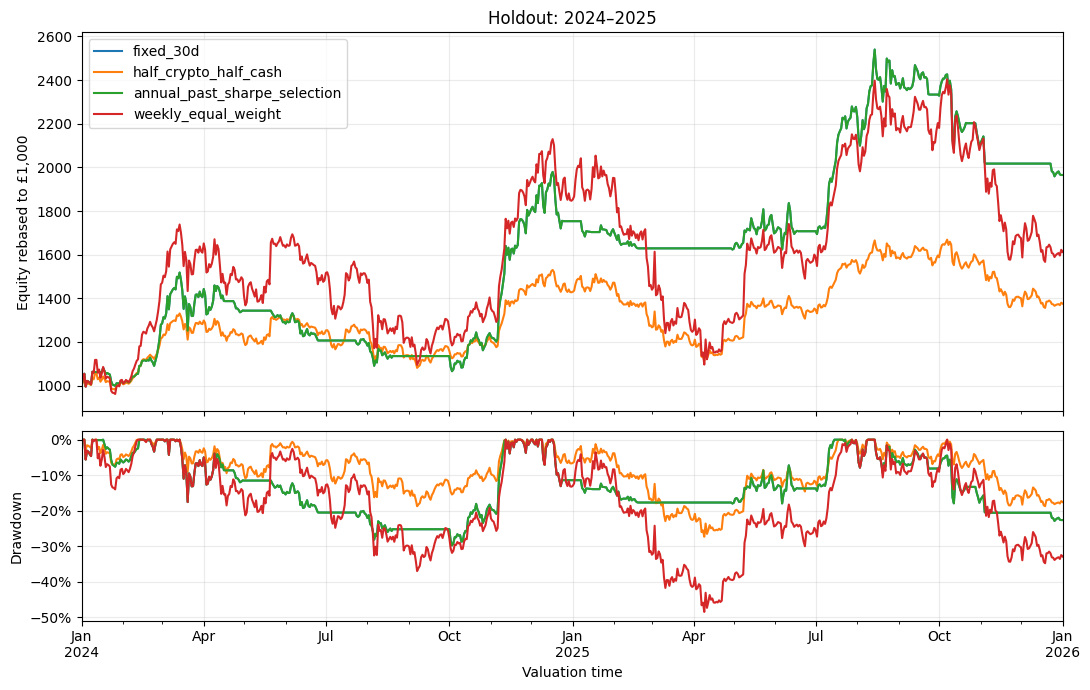

In [9]:
secondary_holdout = crypto_holdout.run_secondary_holdout(
    prices=normalised_prices, primary_result=primary_holdout,
    prior_ledgers={"annual_past_sharpe_selection": selected_ledger,
                   "weekly_equal_weight": development_ledgers["weekly_equal_weight"]},
    prior_selections=lookback_selections)
display(secondary_holdout["holdout_selections"][["lookback_days", "training_end", "training_sharpe"]]
        .style.format({"training_sharpe": "{:.3f}"}))
display(secondary_holdout["cost_summary"][METRICS[:-1]].style.format(FORMATS))
display(secondary_holdout["annual_summary"]["total_return"].unstack("year").style.format("{:.2%}"))
display(crypto_holdout.plot_holdout_equity(secondary_holdout["equity"]))

The selected strategy would've been 30d momentum over the holdout period anyway. See that the strategy was the best performing by Sharpe ratio, CAGR and total returns, even with high transaction costs.

Now also test the daily return and CAGR differences depending on the block days. These are post-holdout, and not primary tests.

In [10]:
exploratory_return_intervals = crypto_replay.replay_exploratory_return_intervals(primary_holdout)
display(exploratory_return_intervals.style.format("{:+.2%}"))

All intervals contain zero, hence no statistical edge has been proved, despite positive results.

## Conclusion 

- Fixed 30d rule produced strong holdout returns, even at 60bp round trip transaction fees
- Primary Sharpe-difference interval contains 0, as do exploratory return-difference intervals. In this study, no statistically significant edge has been established against the benchmark, but that does not prove that there is no advantage.
- Use daily coinbase prices for intended Revolut X execution. The transaction fees are based on 0-9bp maker-taker fees on Revolut X. Spreading/slippage, actual fills, depth, order constraints and capacity are all assumed and unverified. 
- Only two cryptocurrencies are tested, only over two holdout years, so there is limited independent evidence. Development grid chosen adaptively, with holdout now consumed

This project is now complete. Any universe broadening, or execution frequency changing would be included in a subsequent project.

Original notebook available [here](archive/crypto_momentum_research_2026-09-16.ipynb), which includes one off checks and download cells amongst other things.